# MIQR-CC ERCP - Pipeline final para 4 classes


In [1]:
# =========================
# 1. Imports e configuração
# =========================
import os
import json
import copy
import time
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation


In [2]:
# ===================================
# 2. Paths — ajusta se necessário
# ===================================
DATA_ROOT = Path("/mounts/mecd-ap-g5/data")
DATASET_ROOT = DATA_ROOT / "MIQR-CC-Dataset"
METADATA_PATH = DATASET_ROOT / "metadata.csv"

RESULTS_DIR = Path("/mounts/mecd-ap-g5/results/final_4class_pipeline")
MODELS_DIR = Path("/mounts/mecd-ap-g5/models/final_4class_pipeline")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("METADATA_PATH:", METADATA_PATH)
print("Exists:", METADATA_PATH.exists())

METADATA_PATH: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/metadata.csv
Exists: True


In [3]:
# =============================================
# 3. Carregar metadados e criar as 4 classes
# =============================================
df = pd.read_csv(METADATA_PATH)
print("Total inicial:", len(df))
print(df.head())
print("Colunas:", df.columns.tolist())
print("Labels originais:")
print(df["Label"].value_counts(dropna=False))

EXCLUDED_LABELS = {"unlabeled", "unlabelled", "unlabbeled", "nan", "none", ""}

# Manter apenas imagens marcadas como keep e com label válido
keep_mask = df["Keep"].astype(str).str.strip().str.lower().eq("keep")
label_mask = ~df["Label"].astype(str).str.strip().str.lower().isin(EXCLUDED_LABELS)
df = df[keep_mask & label_mask].copy()

# Mapeamento para a tarefa do enunciado: 4 classes
LABEL_MAP = {
    "Benign Stricture": "Stricture",
    "Malignant Stricture": "Stricture",
    "Biliary Leaks": "Biliary Leaks",
    "Biliary_Leaks": "Biliary Leaks",
    "Lithiasis": "Lithiasis",
    "Normal": "Normal",
}

df["label_4class"] = df["Label"].map(LABEL_MAP)
df = df[df["label_4class"].notna()].copy()

# Construir path absoluto da imagem processada
# Nos notebooks anteriores, processed_image_path é relativo a DATASET_ROOT.
df["image_path"] = df["processed_image_path"].apply(lambda p: str(DATASET_ROOT / p))
df = df[df["image_path"].apply(os.path.exists)].copy()

class_names = ["Biliary Leaks", "Lithiasis", "Normal", "Stricture"]
class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for name, i in class_to_idx.items()}
df["target"] = df["label_4class"].map(class_to_idx).astype(int)

print("Total após filtros:", len(df))
print("Distribuição 4 classes:")
print(df["label_4class"].value_counts())
print("Cruzamento tipo imagem x classe:")
print(pd.crosstab(df.get("image_type", "unknown"), df["label_4class"]))

# Guardar metadados limpos
df.to_csv(RESULTS_DIR / "metadata_4class_clean.csv", index=False)

Total inicial: 19317
     raw_image_path    processed_image_path  patient_id image_type sex  \
0  raw/1_image1.png  processed/1_image1.png           1          S   M   
1  raw/1_image2.png  processed/1_image2.png           1          S   M   
2  raw/1_image3.png  processed/1_image3.png           1          S   M   
3  raw/1_image4.png  processed/1_image4.png           1          S   M   
4  raw/2_image5.png  processed/2_image5.png           2          S   F   

   birth_date   exam_date exam_time   age   equipment_model       Label  \
0  22/08/1952  03/02/2022  11:50:32  69.0  Ziehm Vision RFD  Unlabelled   
1  22/08/1952  03/02/2022  11:47:43  69.0  Ziehm Vision RFD  Unlabelled   
2  22/08/1952  03/02/2022  12:08:45  69.0  Ziehm Vision RFD  Unlabelled   
3  22/08/1952  03/02/2022  11:50:22  69.0  Ziehm Vision RFD  Unlabelled   
4  15/08/1925  21/06/2022  20:09:00  96.0  Ziehm Vision RFD   Lithiasis   

      Keep  
0     Keep  
1     Keep  
2     Keep  
3     Keep  
4  Discard  
Colun

In [4]:
# ==========================================
# 4. Split por paciente: treino/val/teste
# ==========================================
# Evita leakage: imagens do mesmo paciente não devem aparecer em splits diferentes.

PATIENT_COL = "patient_id"
assert PATIENT_COL in df.columns, f"Coluna {PATIENT_COL} não existe nos metadados."

patient_summary = (
    df.groupby(PATIENT_COL)
    .agg(
        patient_label=("label_4class", lambda x: x.mode().iloc[0]),
        n_images=("label_4class", "size"),
    )
    .reset_index()
)

print("Pacientes:", len(patient_summary))
print(patient_summary["patient_label"].value_counts())

# Stratified split pode falhar se uma classe tiver muito poucos pacientes.
# Nesse caso, cai para split não estratificado.
def safe_train_test_split(data, test_size, random_state, stratify_col=None):
    try:
        if stratify_col is None:
            return train_test_split(data, test_size=test_size, random_state=random_state)
        return train_test_split(
            data,
            test_size=test_size,
            random_state=random_state,
            stratify=data[stratify_col],
        )
    except ValueError as exc:
        print("Aviso: stratified split falhou. A usar split não estratificado.")
        print("Motivo:", exc)
        return train_test_split(data, test_size=test_size, random_state=random_state)

train_patients, temp_patients = safe_train_test_split(
    patient_summary,
    test_size=0.30,
    random_state=SEED,
    stratify_col="patient_label",
)

val_patients, test_patients = safe_train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED,
    stratify_col="patient_label",
)

train_df = df[df[PATIENT_COL].isin(train_patients[PATIENT_COL])].copy()
val_df = df[df[PATIENT_COL].isin(val_patients[PATIENT_COL])].copy()
test_df = df[df[PATIENT_COL].isin(test_patients[PATIENT_COL])].copy()

for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{split_name.upper()} | imagens={len(split_df)} | pacientes={split_df[PATIENT_COL].nunique()}")
    print(split_df["label_4class"].value_counts())

train_df.to_csv(RESULTS_DIR / "train_split_4class.csv", index=False)
val_df.to_csv(RESULTS_DIR / "val_split_4class.csv", index=False)
test_df.to_csv(RESULTS_DIR / "test_split_4class.csv", index=False)

Pacientes: 436
patient_label
Lithiasis        205
Stricture        104
Normal           101
Biliary Leaks     26
Name: count, dtype: int64
TRAIN | imagens=1001 | pacientes=305
label_4class
Lithiasis        468
Stricture        249
Normal           206
Biliary Leaks     78
Name: count, dtype: int64
VAL | imagens=313 | pacientes=65
label_4class
Lithiasis        142
Stricture         58
Normal            58
Biliary Leaks     55
Name: count, dtype: int64
TEST | imagens=254 | pacientes=66
label_4class
Lithiasis        116
Stricture         85
Normal            35
Biliary Leaks     18
Name: count, dtype: int64


In [5]:
# =====================================
# 5. Dataset + pré-processamento
# =====================================
IMG_SIZE = 320
BATCH_SIZE = 32
NUM_WORKERS = 8
USE_CLAHE = False  # muda para True para testar CLAHE no mesmo pipeline

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def apply_clahe_rgb(pil_image, clip_limit=2.0, tile_grid_size=(8, 8)):
    """Aplica CLAHE no canal L do espaço LAB e devolve PIL RGB."""
    img = np.array(pil_image.convert("RGB"))
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l2 = clahe.apply(l)
    lab2 = cv2.merge((l2, a, b))
    rgb = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)
    return Image.fromarray(rgb)


class ERCPDataset(Dataset):
    def __init__(self, dataframe, transform=None, use_clahe=False, return_metadata=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.use_clahe = use_clahe
        self.return_metadata = return_metadata

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        if self.use_clahe:
            image = apply_clahe_rgb(image)
        if self.transform is not None:
            image = self.transform(image)
        label = int(row["target"])
        if self.return_metadata:
            return image, label, row["image_path"], row["label_4class"]
        return image, label


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.90, 1.10)),
    transforms.ColorJitter(brightness=0.12, contrast=0.12),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = ERCPDataset(train_df, train_transform, use_clahe=USE_CLAHE)
val_dataset = ERCPDataset(val_df, eval_transform, use_clahe=USE_CLAHE)
test_dataset = ERCPDataset(test_df, eval_transform, use_clahe=USE_CLAHE)

# Weighted sampler para lidar com desequilíbrio no treino
class_counts = train_df["target"].value_counts().sort_index()
class_weights_np = len(train_df) / (len(class_names) * class_counts.values)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

weight_lookup = {i: float(w) for i, w in enumerate(class_weights_np)}
sample_weights = train_df["target"].map(weight_lookup).astype(float).values
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Class weights:")
for i, name in enumerate(class_names):
    print(f"{name}: {class_weights[i].item():.3f}")

Class weights:
Biliary Leaks: 3.208
Lithiasis: 0.535
Normal: 1.215
Stricture: 1.005


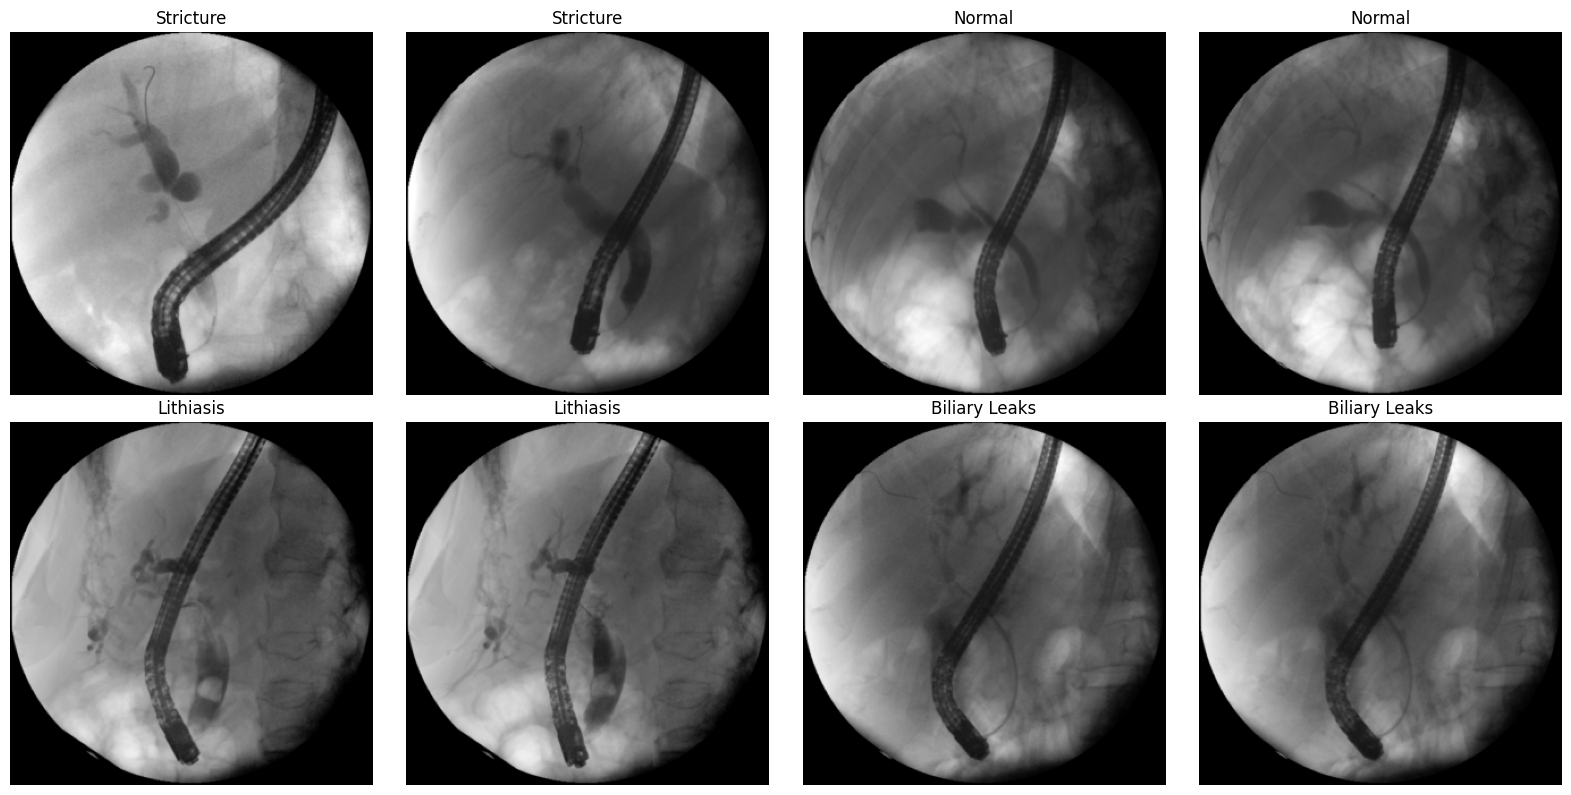

In [6]:
# =========================================
# 6. Visualizar exemplos após preprocessing
# =========================================
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1)

sample_df = train_df.groupby("label_4class", group_keys=False).head(2)
sample_dataset = ERCPDataset(sample_df, eval_transform, use_clahe=USE_CLAHE, return_metadata=True)

cols = 4
rows = int(np.ceil(len(sample_dataset) / cols))
plt.figure(figsize=(4 * cols, 4 * rows))
for i in range(len(sample_dataset)):
    image_tensor, label, path, label_name = sample_dataset[i]
    plt.subplot(rows, cols, i + 1)
    plt.imshow(denormalize(image_tensor).permute(1, 2, 0))
    plt.title(label_name)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
# ==========================================
# 7. Modelo: ConvNeXt / EfficientNet / ResNet
# ==========================================
def build_model(model_name="convnext_tiny", num_classes=4, pretrained=True):
    if model_name == "convnext_tiny":
        weights = models.ConvNeXt_Tiny_Weights.DEFAULT if pretrained else None
        model = models.convnext_tiny(weights=weights)
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)
    elif model_name == "efficientnet_v2_s":
        weights = models.EfficientNet_V2_S_Weights.DEFAULT if pretrained else None
        model = models.efficientnet_v2_s(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
    elif model_name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        model = models.resnet50(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == "densenet121":
        weights = models.DenseNet121_Weights.DEFAULT if pretrained else None
        model = models.densenet121(weights=weights)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    else:
        raise ValueError(f"Modelo não suportado: {model_name}")
    return model

MODEL_NAME = "convnext_tiny"  # experimenta também: efficientnet_v2_s, resnet50, densenet121
model = build_model(MODEL_NAME, num_classes=len(class_names), pretrained=True).to(device)

n_total = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(MODEL_NAME)
print(f"Total params: {n_total:,}")
print(f"Trainable params: {n_trainable:,}")

convnext_tiny
Total params: 27,823,204
Trainable params: 27,823,204


In [8]:
# ========================
# 8. Métricas e avaliação
# ========================
def compute_metrics(y_true, y_pred, y_prob, class_names):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    try:
        metrics["roc_auc_ovr_macro"] = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
    except Exception:
        metrics["roc_auc_ovr_macro"] = np.nan
    try:
        metrics["pr_auc_macro"] = average_precision_score(y_true_bin, y_prob, average="macro")
    except Exception:
        metrics["pr_auc_macro"] = np.nan
    return metrics


def evaluate(model, loader, criterion=None):
    model.eval()
    losses, y_true, y_pred, y_prob = [], [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            if criterion is not None:
                loss = criterion(logits, labels)
                losses.append(loss.item() * images.size(0))
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)
    metrics = compute_metrics(y_true, y_pred, y_prob, class_names)
    metrics["loss"] = np.sum(losses) / len(loader.dataset) if losses else np.nan
    return metrics, y_true, y_pred, y_prob

In [ ]:
# =======================
        # 9. Treino com early stop
        # =======================
NUM_EPOCHS = 25
PATIENCE = 6
LR = 3e-4
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

best_model_state = None
best_val_macro_f1 = -1
best_epoch = -1
patience_counter = 0
history = []

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch}/{NUM_EPOCHS}",
        leave=False,
        dynamic_ncols=True,
        unit="batch",
    )
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        running_loss = train_loss / max(train_total, 1)
        running_acc = train_correct / max(train_total, 1)
        pbar.set_postfix(
            loss=f"{running_loss:.4f}",
            acc=f"{running_acc:.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}",
        )

    train_loss /= len(train_loader.dataset)
    train_acc = train_correct / train_total

    val_metrics, _, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step(val_metrics["macro_f1"])

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        **{f"val_{k}": v for k, v in val_metrics.items()},
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
        f"val_bal_acc={val_metrics['balanced_accuracy']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_macro_f1:
        best_val_macro_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, MODELS_DIR / f"best_{MODEL_NAME}_4class.pt")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping.")
            break

elapsed = time.time() - start_time
print(f"Best epoch: {best_epoch} | best val macro F1: {best_val_macro_f1:.4f} | tempo: {elapsed/60:.1f} min")

history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_DIR / f"history_{MODEL_NAME}_4class.csv", index=False)
model.load_state_dict(torch.load(MODELS_DIR / f"best_{MODEL_NAME}_4class.pt", map_location=device))

Epoch 1/25:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 01 | train_loss=1.2676 | val_loss=1.6245 | val_macro_f1=0.0747 | val_bal_acc=0.2500


Epoch 2/25:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 02 | train_loss=1.1880 | val_loss=1.7182 | val_macro_f1=0.0747 | val_bal_acc=0.2500


Epoch 3/25:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 22/25:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 22 | train_loss=0.0042 | val_loss=3.4987 | val_macro_f1=0.3945 | val_bal_acc=0.4177


Epoch 23/25:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 23 | train_loss=0.0015 | val_loss=3.7824 | val_macro_f1=0.3672 | val_bal_acc=0.3926
Early stopping.
Best epoch: 17 | best val macro F1: 0.4298 | tempo: 6.9 min


<All keys matched successfully>

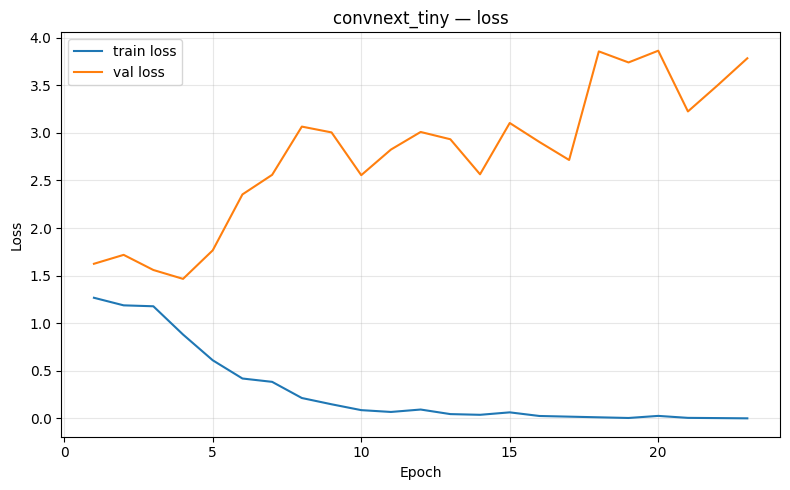

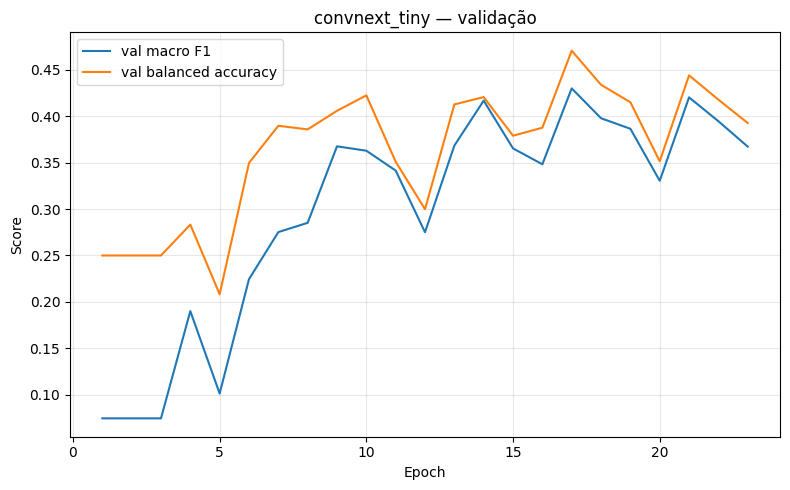

In [10]:
# =========================
# 10. Curvas de treino
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{MODEL_NAME} — loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"loss_curve_{MODEL_NAME}.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="val macro F1")
plt.plot(history_df["epoch"], history_df["val_balanced_accuracy"], label="val balanced accuracy")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title(f"{MODEL_NAME} — validação")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"validation_scores_{MODEL_NAME}.png", dpi=200)
plt.show()

In [ ]:
# ==========================
# 11. Avaliação no teste
# ==========================
test_metrics, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion)

print("Métricas de teste:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

print("Classification report:")
report_text = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
print(report_text)

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
with open(RESULTS_DIR / f"classification_report_{MODEL_NAME}_4class.json", "w") as f:
    json.dump(report_dict, f, indent=2)

pd.DataFrame([test_metrics]).to_csv(RESULTS_DIR / f"test_metrics_{MODEL_NAME}_4class.csv", index=False)

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(RESULTS_DIR / f"confusion_matrix_{MODEL_NAME}_4class.csv")

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Matriz de confusão — {MODEL_NAME}")
plt.colorbar()
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)
plt.xlabel("Predito")
plt.ylabel("Real")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(RESULTS_DIR / f"confusion_matrix_{MODEL_NAME}_4class.png", dpi=200)
plt.show()

In [ ]:
# ======================================================
# 12. Guardar previsões para analisar erros depois
# ======================================================
test_predictions = test_df.reset_index(drop=True).copy()
test_predictions["y_true"] = y_true
test_predictions["y_pred"] = y_pred
test_predictions["true_label"] = [idx_to_class[i] for i in y_true]
test_predictions["pred_label"] = [idx_to_class[i] for i in y_pred]
test_predictions["correct"] = test_predictions["y_true"] == test_predictions["y_pred"]

for i, name in enumerate(class_names):
    test_predictions[f"prob_{name}"] = y_prob[:, i]

test_predictions.to_csv(RESULTS_DIR / f"test_predictions_{MODEL_NAME}_4class.csv", index=False)

print("Erros por classe real:")
print(test_predictions[~test_predictions["correct"]]["true_label"].value_counts())

test_predictions.sort_values("correct").head(10)[[
    "image_path", "true_label", "pred_label", "correct"
]]

In [ ]:
# =========================
# 13. Grad-CAM obrigatório
# =========================
# Implementação simples de Grad-CAM sem bibliotecas externas.

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.fwd_handle = target_layer.register_forward_hook(self._forward_hook)
        self.bwd_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, image_tensor, class_idx=None):
        self.model.eval()
        image_tensor = image_tensor.unsqueeze(0).to(device)
        logits = self.model(image_tensor)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        self.model.zero_grad(set_to_none=True)
        score = logits[:, class_idx].sum()
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1).squeeze()
        cam = torch.relu(cam)
        cam = cam.cpu().numpy()
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()[0]
        pred_idx = int(np.argmax(probs))
        return cam, pred_idx, probs

    def close(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()


def get_gradcam_layer(model, model_name):
    if model_name == "resnet50":
        return model.layer4[-1]
    if model_name == "densenet121":
        return model.features[-1]
    if model_name == "efficientnet_v2_s":
        return model.features[-1]
    if model_name == "convnext_tiny":
        return model.features[-1]
    raise ValueError(model_name)


def show_gradcam_for_row(row, gradcam, alpha=0.45, save_path=None):
    original = Image.open(row["image_path"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    processed = apply_clahe_rgb(original) if USE_CLAHE else original
    image_tensor = eval_transform(processed)

    cam, pred_idx, probs = gradcam(image_tensor)
    pred_label = idx_to_class[pred_idx]
    true_label = row["label_4class"]

    original_np = np.array(original) / 255.0
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = np.clip((1 - alpha) * original_np + alpha * heatmap, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(original_np)
    axes[0].set_title(f"Original
Real: {true_label}")
    axes[0].axis("off")

    axes[1].imshow(cam, cmap="jet")
    axes[1].set_title("Grad-CAM")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title(f"Overlay
Pred: {pred_label} ({probs[pred_idx]:.2f})")
    axes[2].axis("off")

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    return {"true": true_label, "pred": pred_label, "prob": float(probs[pred_idx])}

In [ ]:
# ========================================================
# 14. Gerar Grad-CAM para exemplos corretos e incorretos
# ========================================================
gradcam = GradCAM(model, get_gradcam_layer(model, MODEL_NAME))

GRADCAM_DIR = RESULTS_DIR / "gradcam_examples"
GRADCAM_DIR.mkdir(parents=True, exist_ok=True)

# 1 exemplo correto por classe
correct_examples = test_predictions[test_predictions["correct"]].groupby("true_label", group_keys=False).head(1)
print("Exemplos corretos:")
for _, row in correct_examples.iterrows():
    safe_name = row["true_label"].replace(" ", "_")
    show_gradcam_for_row(row, gradcam, save_path=GRADCAM_DIR / f"correct_{safe_name}.png")

# Alguns erros, se existirem
wrong_examples = test_predictions[~test_predictions["correct"]].head(4)
print("Exemplos incorretos:")
for i, (_, row) in enumerate(wrong_examples.iterrows()):
    safe_true = row["true_label"].replace(" ", "_")
    safe_pred = row["pred_label"].replace(" ", "_")
    show_gradcam_for_row(row, gradcam, save_path=GRADCAM_DIR / f"wrong_{i}_{safe_true}_as_{safe_pred}.png")

gradcam.close()

In [ ]:
# ========================================
# 15. Resumo para relatório
# ========================================
summary = {
    "model": MODEL_NAME,
    "num_classes": len(class_names),
    "classes": class_names,
    "use_clahe": USE_CLAHE,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "weight_decay": WEIGHT_DECAY,
    "best_epoch": int(best_epoch),
    "best_val_macro_f1": float(best_val_macro_f1),
    "test_metrics": {k: float(v) if not pd.isna(v) else None for k, v in test_metrics.items()},
    "baseline_from_statement_macro_f1": 0.738,
}

with open(RESULTS_DIR / f"summary_{MODEL_NAME}_4class.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print("Ficheiros guardados em:", RESULTS_DIR)
print("Modelo guardado em:", MODELS_DIR / f"best_{MODEL_NAME}_4class.pt")